生成数据形状: (5, 1000)
真实ARMA参数：phi1=0.6, theta1=-0.4
ADF检验p值: 0.0000
✅ 序列平稳（拒绝非平稳原假设）
基于AIC最优阶数: (1, 1) (AIC=7347.36)
基于BIC最优阶数: (1, 1) (BIC=7373.42)
最终选择ARMA阶数：p=1, q=1

=== 拟合的ARMA模型参数 ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0051      0.023     -0.219      0.826      -0.051       0.041
ar.L1          0.5704      0.015     38.985      0.000       0.542       0.599
ma.L1          0.4084      0.017     24.729      0.000       0.376       0.441
sigma2         0.2540      0.005     49.466      0.000       0.244       0.264

=== 残差Ljung-Box检验 ===
滞后20期p值均值: 0.8635
✅ 残差为白噪声（无法拒绝原假设）


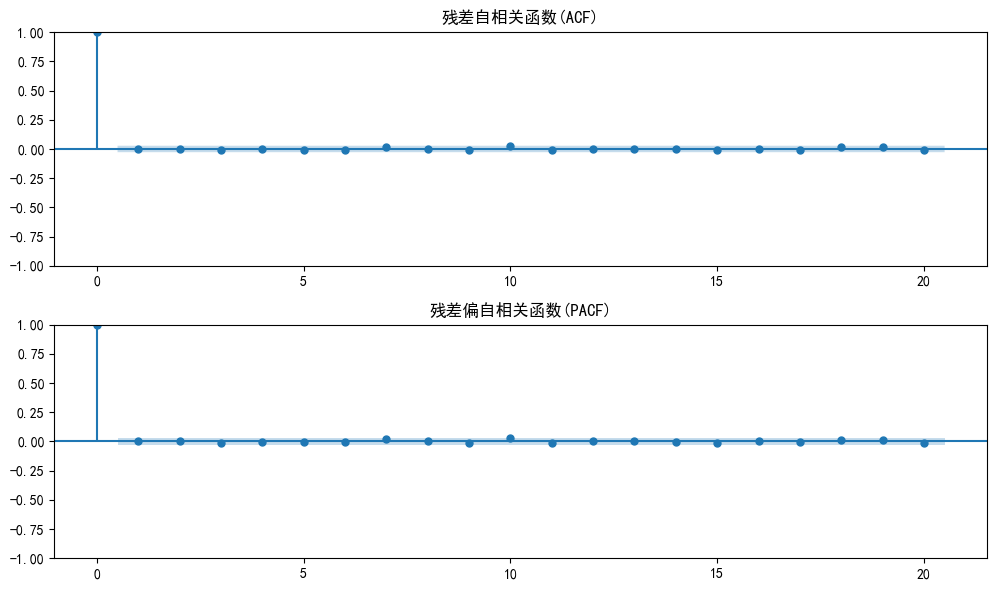


生成数据形状: (5, 1000)


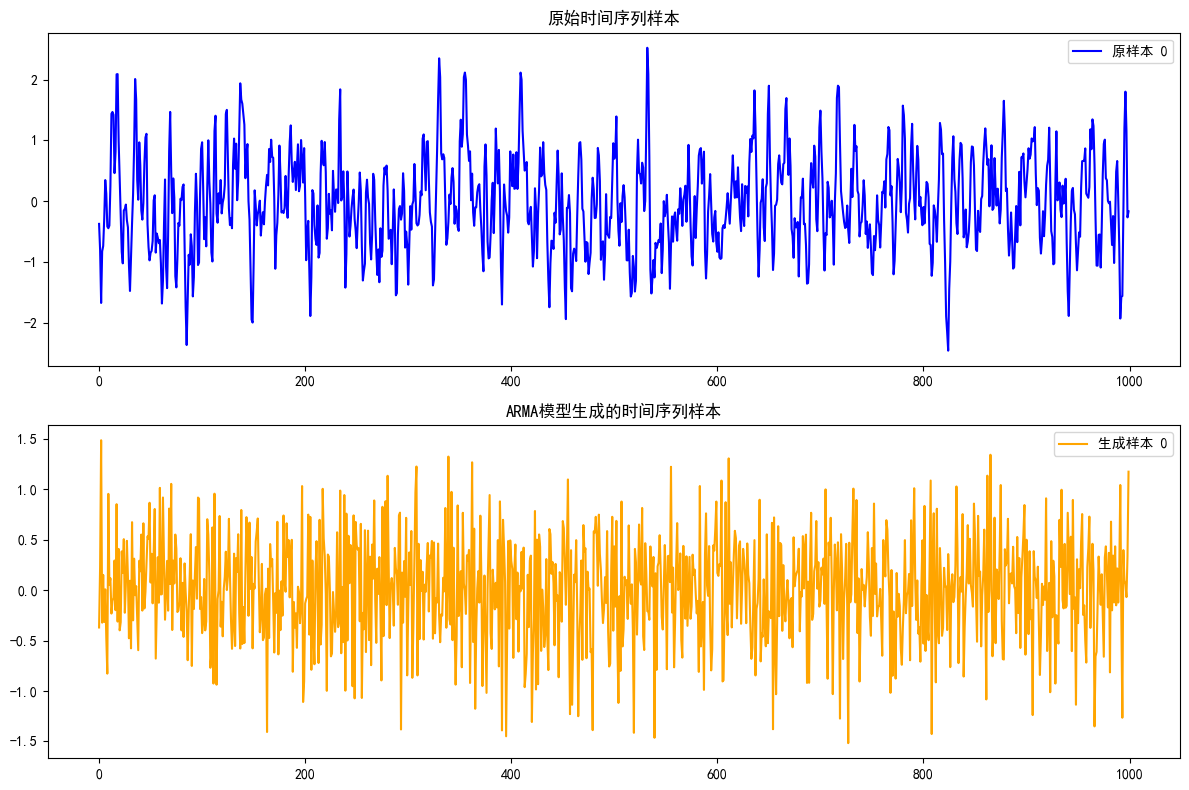


=== 样本0统计特性对比 ===
原样本 - 均值: -0.0235, 方差: 0.5940
生成样本 - 均值: 0.0055, 方差: 0.2660


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA  # ARMA(p,q) = ARIMA(p,0,q)
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings("ignore")  # 屏蔽statsmodels的冗余警告

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 显示中文
plt.rcParams["axes.unicode_minus"] = False  # 显示负号


# ===================== 步骤1：生成模拟测试数据（替换为你的真实数据） =====================
# 模拟参数：AR(1) + MA(1)，即ARMA(1,1)，方便验证拟合效果
# 真实参数：phi1=0.6（AR系数），theta1=-0.4（MA系数）
def generate_arma_samples(num_samples, seq_len, phi1=0.6, theta1=-0.4, sigma=0.5):
    """生成[num_samples, seq_len]形状的ARMA(1,1)平稳时间序列样本"""
    samples = []
    for _ in range(num_samples):
        # 初始化白噪声（激励源）和时间序列
        eps = np.random.normal(0, sigma, seq_len)  # 白噪声序列
        x = np.zeros(seq_len)
        x[0] = eps[0]  # 初始值

        # 递归生成ARMA(1,1)序列：Xt = phi1*Xt-1 + eps_t - theta1*eps_t-1
        for t in range(1, seq_len):
            x[t] = phi1 * x[t - 1] + eps[t] - theta1 * eps[t - 1]
        samples.append(x)
    return np.array(samples), phi1, theta1


# 生成测试数据：5个样本，每个样本长度1000
num_samples = 5
seq_len = 1000
arma_samples, true_phi1, true_theta1 = generate_arma_samples(num_samples, seq_len)
print(f"生成数据形状: {arma_samples.shape}")
print(f"真实ARMA参数：phi1={true_phi1}, theta1={true_theta1}")
# df = pd.read_csv("data/spec4_data.csv")

# num_samples = 4
# seq_len = 500
# arma_samples = df.values.T[1:, :seq_len]
# print(f"加载数据形状: {arma_samples.shape}")

# ===================== 步骤2：数据预处理（合并样本+平稳性检验） =====================
# 合并多样本为单长序列（前提：样本间统计特性一致）
merged_series = arma_samples.flatten()
# 转换为pandas Series（方便statsmodels处理）
ts = pd.Series(merged_series)


# 平稳性检验（ADF单位根检验）
def adf_test(series, signif=0.05):
    """ADF检验：p值<signif则序列平稳"""
    adf_result = adfuller(series)
    p_value = adf_result[1]
    print(f"ADF检验p值: {p_value:.4f}")
    if p_value < signif:
        print("✅ 序列平稳（拒绝非平稳原假设）")
        return True
    else:
        print("❌ 序列非平稳（需差分处理）")
        return False


# 执行平稳性检验
is_stationary = adf_test(ts)


# ===================== 步骤3：确定ARMA阶数(p,q) =====================
def select_arma_order(series, max_p=3, max_q=3):
    """通过AIC/BIC准则选择最优(p,q)阶数"""
    best_aic = np.inf
    best_bic = np.inf
    best_order = (0, 0)

    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue  # 跳过无意义的(0,0)阶
            try:
                model = ARIMA(series, order=(p, 0, q))  # ARIMA(p,0,q)=ARMA(p,q)
                results = model.fit()
                # 记录最优阶数
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order_aic = (p, q)
                if results.bic < best_bic:
                    best_bic = results.bic
                    best_order_bic = (p, q)
            except:
                continue  # 跳过无法拟合的阶数

    print(f"基于AIC最优阶数: {best_order_aic} (AIC={best_aic:.2f})")
    print(f"基于BIC最优阶数: {best_order_bic} (BIC={best_bic:.2f})")
    return best_order_bic  # BIC更倾向于简约模型，优先选择


# 选择最优阶数（max_p/max_q可根据需求调整）
best_p, best_q = select_arma_order(ts, max_p=3, max_q=3)
print(f"最终选择ARMA阶数：p={best_p}, q={best_q}")

# ===================== 步骤4：拟合ARMA(p,q)模型 =====================
# 拟合ARMA模型（ARIMA(p,0,q)）
model = ARIMA(ts, order=(best_p, 0, best_q))
arma_results = model.fit()

# 输出模型参数（与真实参数对比）
print("\n=== 拟合的ARMA模型参数 ===")
print(arma_results.summary().tables[1])  # 只打印参数表


# ===================== 步骤5：模型诊断（残差白噪声检验） =====================
def residual_diagnosis(residuals, signif=0.05):
    """残差白噪声检验：Ljung-Box + ACF/PACF可视化"""
    # 1. Ljung-Box检验（p值>signif则残差无自相关，即白噪声）
    lb_test = acorr_ljungbox(residuals, lags=20, return_df=True)
    lb_p_values = lb_test["lb_pvalue"]
    print(f"\n=== 残差Ljung-Box检验 ===")
    print(f"滞后20期p值均值: {lb_p_values.mean():.4f}")
    if all(lb_p_values > signif):
        print("✅ 残差为白噪声（无法拒绝原假设）")
    else:
        print("❌ 残差非白噪声（模型拟合不足）")

    # 2. 可视化残差的ACF/PACF（无显著自相关则为白噪声）
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(residuals, lags=20, ax=ax1, title="残差自相关函数(ACF)")
    plot_pacf(residuals, lags=20, ax=ax2, title="残差偏自相关函数(PACF)")
    plt.tight_layout()
    plt.show()


# 提取残差并诊断
residuals = arma_results.resid
residual_diagnosis(residuals)


# ===================== 步骤6：用白噪声激励模型生成新数据 =====================
def generate_arma_data(model_results, n_steps, sigma=None):
    """
    用白噪声激励ARMA模型生成新数据
    :param model_results: 拟合好的ARMA模型结果
    :param n_steps: 生成序列长度
    :param sigma: 白噪声方差（默认用模型拟合的残差方差）
    :return: 生成的时间序列
    """
    # 获取模型参数
    p = model_results.model.order[0]
    q = model_results.model.order[2]
    ar_params = model_results.params.filter(regex="ar").values  # AR系数
    ma_params = model_results.params.filter(regex="ma").values  # MA系数

    # 白噪声序列（激励源）：默认用残差的标准差
    if sigma is None:
        sigma = residuals.std()
    eps = np.random.normal(0, sigma, n_steps + q)  # 多生成q个用于MA项

    # 初始化生成序列
    gen_series = np.zeros(n_steps)
    # 初始值：用原序列的前p个值（或全0，这里用原序列初始值更贴近）
    gen_series[: min(p, n_steps)] = ts[: min(p, n_steps)].values

    # 递归生成ARMA序列：Xt = sum(ar*Xt-i) + eps_t - sum(ma*eps_t-j)
    for t in range(p, n_steps):
        # AR项：sum(phi_i * Xt-i)
        ar_term = np.sum(ar_params * gen_series[t - p : t][::-1]) if p > 0 else 0
        # MA项：sum(theta_j * eps_t-j)
        ma_term = np.sum(ma_params * eps[t - q : t][::-1]) if q > 0 else 0
        # 核心公式
        gen_series[t] = ar_term + eps[t] - ma_term

    return gen_series


# 生成新数据：长度与原单样本一致（1000），生成5个样本（与原数据数量一致）
gen_num_samples = num_samples
gen_seq_len = seq_len
generated_samples = []
for _ in range(gen_num_samples):
    gen_series = generate_arma_data(arma_results, gen_seq_len)
    generated_samples.append(gen_series)
generated_samples = np.array(generated_samples)
print(f"\n生成数据形状: {generated_samples.shape}")


# ===================== 步骤7：可视化对比原数据和生成数据 =====================
def plot_compare(original, generated, sample_idx=0):
    """对比原数据和生成数据的单个样本"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    # 绘制原样本
    ax1.plot(original[sample_idx], label=f"原样本 {sample_idx}", color="blue")
    ax1.set_title("原始时间序列样本")
    ax1.legend()
    # 绘制生成样本
    ax2.plot(generated[sample_idx], label=f"生成样本 {sample_idx}", color="orange")
    ax2.set_title("ARMA模型生成的时间序列样本")
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # 统计特性对比
    print(f"\n=== 样本{sample_idx}统计特性对比 ===")
    print(
        f"原样本 - 均值: {original[sample_idx].mean():.4f}, 方差: {original[sample_idx].var():.4f}"
    )
    print(
        f"生成样本 - 均值: {generated[sample_idx].mean():.4f}, 方差: {generated[sample_idx].var():.4f}"
    )


# 对比第0个样本
plot_compare(arma_samples, generated_samples, sample_idx=0)

非平稳样本形状: (5, 1000)
=== 原始序列检验 ===

原始非平稳序列 ADF检验p值: 0.0000
✅ 原始非平稳序列 平稳

最终确定差分阶数d=0
尝试ARIMA(0,0,1)
尝试ARIMA(0,0,2)
尝试ARIMA(0,0,3)
尝试ARIMA(0,0,4)
尝试ARIMA(0,0,5)
尝试ARIMA(1,0,0)
尝试ARIMA(1,0,1)
尝试ARIMA(1,0,2)
尝试ARIMA(1,0,3)
尝试ARIMA(1,0,4)
尝试ARIMA(1,0,5)
尝试ARIMA(2,0,0)
尝试ARIMA(2,0,1)
尝试ARIMA(2,0,2)
尝试ARIMA(2,0,3)
尝试ARIMA(2,0,4)
尝试ARIMA(2,0,5)
尝试ARIMA(3,0,0)
尝试ARIMA(3,0,1)
尝试ARIMA(3,0,2)
尝试ARIMA(3,0,3)
尝试ARIMA(3,0,4)
尝试ARIMA(3,0,5)
尝试ARIMA(4,0,0)
尝试ARIMA(4,0,1)
尝试ARIMA(4,0,2)
尝试ARIMA(4,0,3)
尝试ARIMA(4,0,4)
尝试ARIMA(4,0,5)
尝试ARIMA(5,0,0)
尝试ARIMA(5,0,1)
尝试ARIMA(5,0,2)
尝试ARIMA(5,0,3)
尝试ARIMA(5,0,4)
尝试ARIMA(5,0,5)
基于AIC最优(p,q): (5, 5) (AIC=-10755.61)
基于BIC最优(p,q): (5, 5) (BIC=-10677.41)
最终ARIMA阶数：p=5, d=0, q=5

=== ARIMA模型参数 ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5112      0.095      5.403      0.000       0.326       0.697
ar.L1          1.2233      0.227    

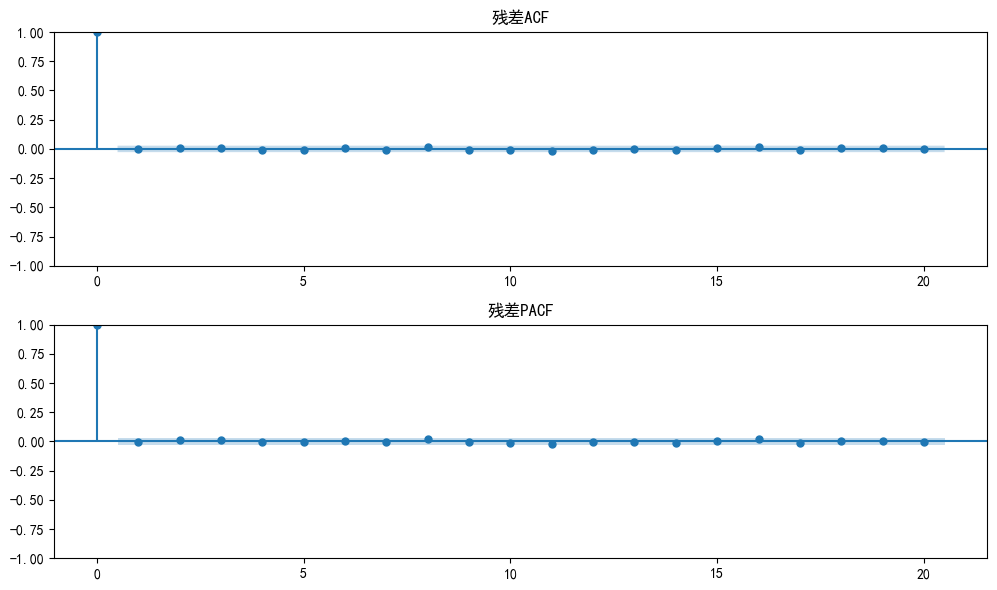


生成非平稳数据形状: (5, 1000)


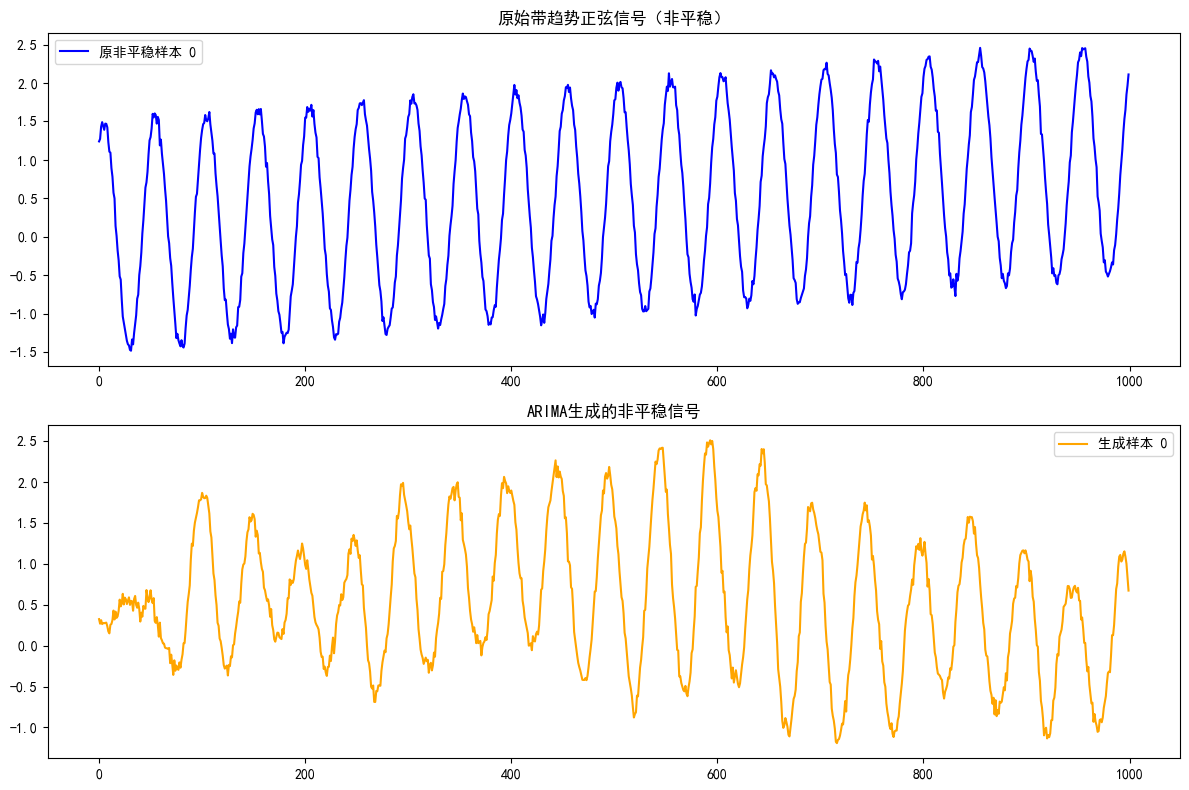


=== 样本0统计特性对比 ===
原样本 - 均值: 0.4998, 方差: 1.1958
生成样本 - 均值: 0.5389, 方差: 0.7498


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 显示中文
plt.rcParams["axes.unicode_minus"] = False  # 显示负号


# ===================== 步骤1：生成非平稳测试数据（带线性趋势的正弦信号） =====================
def generate_nonstationary_sine(
    num_samples, seq_len, freq=2.0, sample_rate=100, amp=1.5
):
    """生成带线性趋势的非平稳正弦信号 [num_samples, seq_len]"""
    t = np.linspace(0, seq_len / sample_rate, seq_len, endpoint=False)
    nonstationary_samples = []

    for _ in range(num_samples):
        phase = np.random.uniform(0, 2 * np.pi)
        # 正弦信号 + 线性趋势（导致非平稳） + 微小噪声
        sine_seq = amp * np.sin(2 * np.pi * freq * t + phase)
        trend = 0.1 * t  # 线性趋势：随时间递增，核心非平稳来源
        noise = np.random.normal(0, 0.05, seq_len)
        nonstationary_seq = sine_seq + trend + noise
        nonstationary_samples.append(nonstationary_seq)

    return np.array(nonstationary_samples), freq, sample_rate


# 生成非平稳样本
num_samples = 5
seq_len = 1000
target_freq = 2.0
sample_rate = 100
nonstationary_samples, true_freq, sr = generate_nonstationary_sine(
    num_samples=num_samples, seq_len=seq_len, freq=target_freq, sample_rate=sample_rate
)
print(f"非平稳样本形状: {nonstationary_samples.shape}")

# 合并为单序列
merged_series = nonstationary_samples.flatten()
ts = pd.Series(merged_series, name="nonstationary_sine")


# ===================== 步骤2：检验非平稳性 + 确定差分阶数d =====================
def adf_test(series, name="序列", signif=0.05):
    """ADF检验，返回是否平稳"""
    adf_result = adfuller(series.dropna())  # 差分后会有NaN，需删除
    p_value = adf_result[1]
    print(f"\n{name} ADF检验p值: {p_value:.4f}")
    if p_value < signif:
        print(f"✅ {name} 平稳")
        return True
    else:
        print(f"❌ {name} 非平稳")
        return False


# 检验原始序列（必然非平稳）
print("=== 原始序列检验 ===")
is_stationary = adf_test(ts, "原始非平稳序列")

# 逐次差分，确定d（通常d=1即可）
d = 0
diff_series = ts.copy()
while not is_stationary and d < 3:  # 最多试2阶差分
    d += 1
    diff_series = diff_series.diff().dropna()  # d阶差分
    print(f"\n=== {d}阶差分后序列检验 ===")
    is_stationary = adf_test(diff_series, f"{d}阶差分序列")

print(f"\n最终确定差分阶数d={d}")


# ===================== 步骤3：选择ARIMA(p,d,q)的p和q =====================
def select_arima_order(stationary_series, max_p=8, max_q=8):
    """对平稳序列选择ARMA(p,q)阶数（即ARIMA的p,q）"""
    best_aic = np.inf
    best_bic = np.inf
    best_order_aic = (0, 0)
    best_order_bic = (0, 0)

    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                print(f"尝试ARIMA({p},{0},{q})")
                model = ARIMA(stationary_series, order=(p, 0, q))
                results = model.fit()
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order_aic = (p, q)
                if results.bic < best_bic:
                    best_bic = results.bic
                    best_order_bic = (p, q)
            except:
                continue

    print(f"基于AIC最优(p,q): {best_order_aic} (AIC={best_aic:.2f})")
    print(f"基于BIC最优(p,q): {best_order_bic} (BIC={best_bic:.2f})")
    return best_order_bic


# 对差分后的平稳序列选p,q
best_p, best_q = select_arima_order(diff_series, max_p=5, max_q=5)
print(f"最终ARIMA阶数：p={best_p}, d={d}, q={best_q}")

# ===================== 步骤4：拟合ARIMA(p,d,q)模型 =====================
model = ARIMA(ts, order=(best_p, d, best_q))
arima_results = model.fit()
print("\n=== ARIMA模型参数 ===")
print(arima_results.summary().tables[1])


# ===================== 步骤5：模型诊断（残差白噪声检验） =====================
def residual_diagnosis(residuals, signif=0.05):
    residuals = residuals.dropna()
    # Ljung-Box检验
    lb_test = acorr_ljungbox(residuals, lags=20, return_df=True)
    lb_p_values = lb_test["lb_pvalue"]
    print(f"\n=== 残差Ljung-Box检验 ===")
    print(f"滞后20期p值均值: {lb_p_values.mean():.4f}")
    if all(lb_p_values > signif):
        print("✅ 残差为白噪声")
    else:
        print("❌ 残差非白噪声（模型拟合不足）")

    # 可视化残差ACF/PACF
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(residuals, lags=20, ax=ax1, title="残差ACF")
    plot_pacf(residuals, lags=20, ax=ax2, title="残差PACF")
    plt.tight_layout()
    plt.show()


residuals = arima_results.resid
residual_diagnosis(residuals)


# ===================== 步骤6：生成非平稳数据（修复核心：去掉initial_state） =====================
def generate_arima_data(model_results, n_steps, random_seed=None):
    """
    修复版：生成ARIMA数据（自动逆差分，不手动指定initial_state）
    :param model_results: 拟合的ARIMA结果
    :param n_steps: 生成长度
    :param random_seed: 随机种子（可选，保证可复现）
    :return: 非平稳生成序列
    """
    # 关键修复：不指定initial_state，让模型自动生成适配维度的初始状态
    # simulate方法会自动完成逆差分，直接返回非平稳序列
    gen_series = model_results.simulate(
        nsimulations=n_steps, random_state=random_seed  # 可选：固定随机种子，结果可复现
    )
    return gen_series.values


# 生成与原样本长度一致的非平稳数据（每个样本seq_len，共num_samples个）
gen_num_samples = num_samples
gen_seq_len = seq_len
generated_samples = []
for i in range(gen_num_samples):
    # 每个样本用不同随机种子，避免生成完全相同的序列
    gen_series = generate_arima_data(arima_results, gen_seq_len, random_seed=i)
    generated_samples.append(gen_series)
generated_samples = np.array(generated_samples)
print(f"\n生成非平稳数据形状: {generated_samples.shape}")


# ===================== 步骤7：可视化对比 =====================
def plot_compare(original, generated, sample_idx=0):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    # 原非平稳样本
    ax1.plot(original[sample_idx], label=f"原非平稳样本 {sample_idx}", color="blue")
    ax1.set_title("原始带趋势正弦信号（非平稳）")
    ax1.legend()
    # 生成样本
    ax2.plot(generated[sample_idx], label=f"生成样本 {sample_idx}", color="orange")
    ax2.set_title("ARIMA生成的非平稳信号")
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # 统计特性对比
    print(f"\n=== 样本{sample_idx}统计特性对比 ===")
    print(
        f"原样本 - 均值: {original[sample_idx].mean():.4f}, 方差: {original[sample_idx].var():.4f}"
    )
    print(
        f"生成样本 - 均值: {generated[sample_idx].mean():.4f}, 方差: {generated[sample_idx].var():.4f}"
    )


# 对比第0个样本
plot_compare(nonstationary_samples, generated_samples, sample_idx=0)

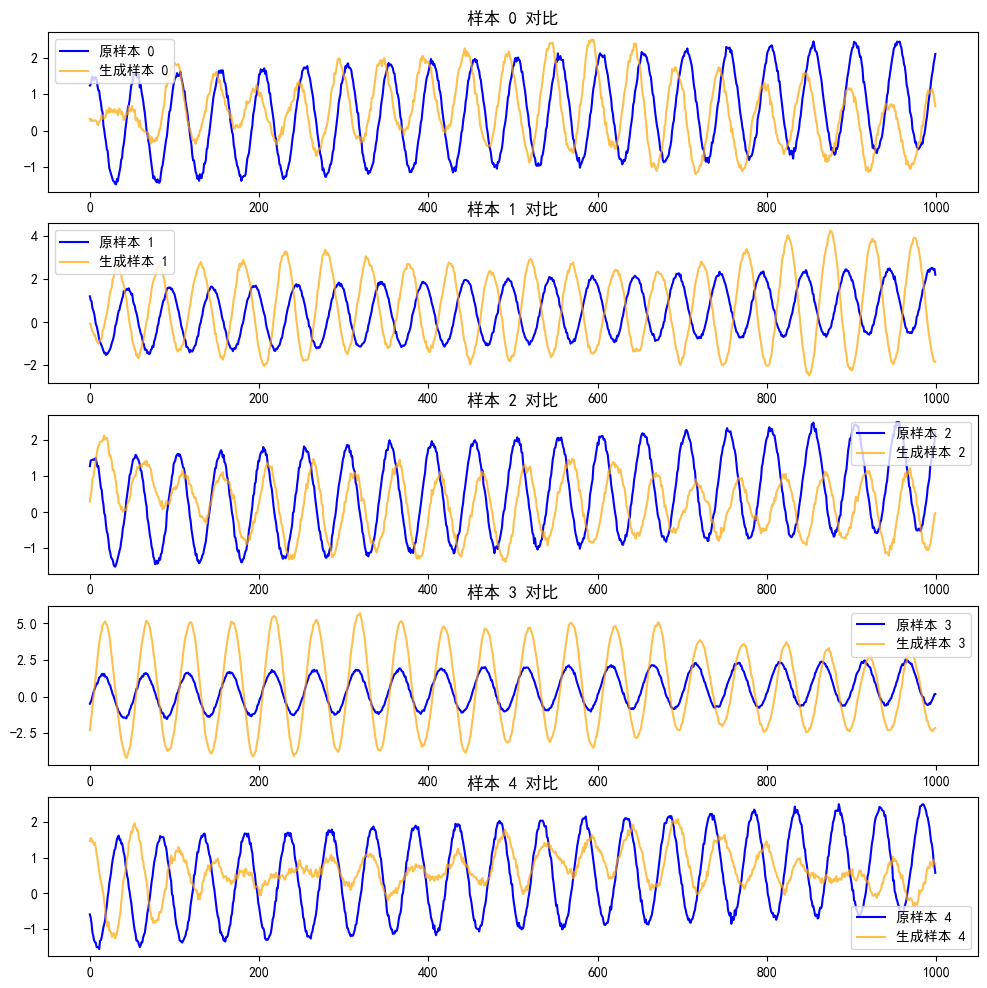

In [5]:
fig, ax = plt.subplots(5, 1, figsize=(12, 12))

for i in range(5):
    ax[i].plot(nonstationary_samples[i], label=f"原样本 {i}", color="blue")
    ax[i].plot(generated_samples[i], label=f"生成样本 {i}", color="orange", alpha=0.7)
    ax[i].set_title(f"样本 {i} 对比")
    ax[i].legend()

In [6]:
def ResNormCheck(residuals, bins=13, save=False, dpi=1500):
    import numpy as np
    from statsmodels.graphics.gofplots import qqplot
    from scipy.stats import shapiro
    from matplotlib.pylab import mpl
    from matplotlib import pyplot as plt
    import seaborn as sns

    sns.set_theme(style="ticks")

    stat, p_value = shapiro(residuals)
    print(f"Shapiro-Wilk Test Stat={stat}, p-value={p_value}")

    fig, ax = plt.subplots(1, 2, figsize=(12.1, 5))
    fig.subplots_adjust(wspace=0.16)

    ax[0].hist(residuals, bins=bins, alpha=1, color="w", edgecolor="k", lw=1.2)
    qqplot(
        residuals,
        line="s",
        ax=ax[1],
        markerfacecolor="white",
        markeredgecolor="k",
        markersize=7.5,
    )
    for line in ax[1].get_lines():
        if line.get_linestyle() == "-":
            line.set_color("#DC143C")
            line.set_linewidth(2.1)

    ax[0].grid(which="major", color="gray", linestyle="--", lw=0.5, alpha=0.8)
    ax[1].grid(which="major", color="gray", linestyle="--", lw=0.5, alpha=0.8)

    mpl.rcParams["font.sans-serif"] = ["SimHei"]
    mpl.rcParams["axes.unicode_minus"] = False

    ax[0].set_xlabel("标准残差", fontsize=12.5)
    ax[0].set_ylabel("频率", fontsize=12.5)

    ax[1].set_xlabel("理论分位数", fontsize=12.5)
    ax[1].set_ylabel("样本分位数", fontsize=12.5)

    mean = np.round(np.mean(residuals), 4)
    std = np.round(np.std(residuals), 4)
    stat = np.round(stat, 4)
    p_value = np.round(p_value, 4)

    ax[0].text(
        0.05,
        0.95,
        f"$\mu$ = {mean}\n$\sigma$ = {std}",
        transform=ax[0].transAxes,
        verticalalignment="top",
        horizontalalignment="left",
        fontsize=13.5,
        color="k",
    )
    ax[1].text(
        0.05,
        0.95,
        f"$W$ = {stat}\n$p$ = {p_value}",
        transform=ax[1].transAxes,
        verticalalignment="top",
        horizontalalignment="left",
        fontsize=13.5,
        color="k",
    )

    if save:
        fig.savefig("Hist_QQplot.jpg", dpi=dpi, bbox_inches="tight")

Shapiro-Wilk Test Stat=0.7403268702133885, p-value=1.269731487362425e-66


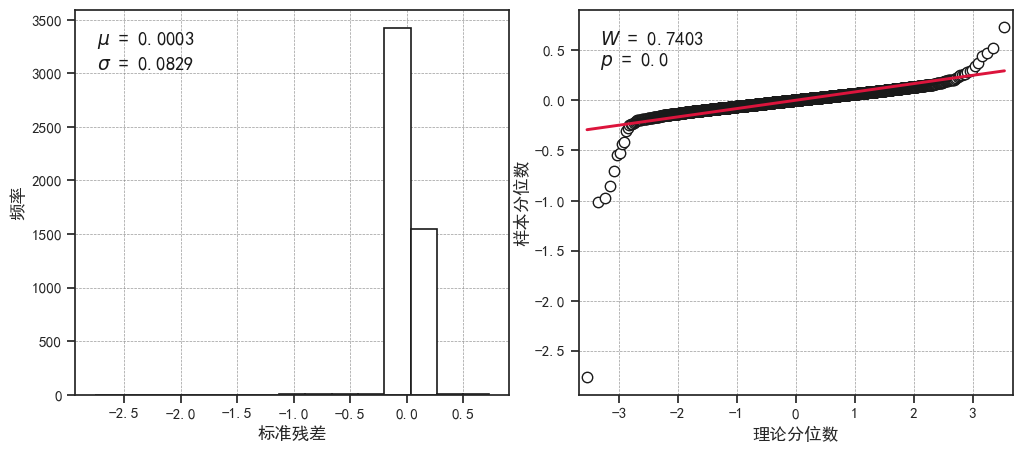

In [7]:
residuals = arima_results.resid
ResNormCheck(residuals, bins=15, save=False, dpi=1500)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf, eacf  # 保留eacf计算函数
from scipy import stats


def select_arma_order(series, max_p=3, max_q=3):
    """通过AIC/BIC准则选择最优(p,q)阶数"""
    best_aic = np.inf
    best_bic = np.inf
    best_order_aic = (0, 0)
    best_order_bic = (0, 0)

    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue  # 跳过无意义的(0,0)阶
            try:
                model = ARIMA(series, order=(p, 0, q))  # ARIMA(p,0,q)=ARMA(p,q)
                results = model.fit()
                # 记录最优阶数
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order_aic = (p, q)
                if results.bic < best_bic:
                    best_bic = results.bic
                    best_order_bic = (p, q)
            except:
                continue  # 跳过无法拟合的阶数

    print(f"基于AIC最优阶数: {best_order_aic} (AIC={best_aic:.2f})")
    print(f"基于BIC最优阶数: {best_order_bic} (BIC={best_bic:.2f})")
    return best_order_aic, best_order_bic


def plot_eacf_manual(series, max_lag=6, alpha=0.05):
    """手动实现EACF绘图（替代statsmodels的plot_eacf）"""
    # 计算EACF矩阵和滞后阶数
    eacf_mat, lags = eacf(series, max_lag=max_lag, alpha=alpha)
    n = len(series)
    threshold = stats.norm.ppf(1 - alpha / 2) / np.sqrt(n)  # 95%置信区间阈值

    # 绘制EACF热力图（更直观展示零值区域）
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(eacf_mat, cmap="RdBu_r", vmin=-threshold, vmax=threshold)

    # 添加网格和标注
    ax.set_xticks(np.arange(len(lags)))
    ax.set_yticks(np.arange(len(lags)))
    ax.set_xticklabels([f"q={int(l)}" for l in lags])
    ax.set_yticklabels([f"p={int(l)}" for l in lags])

    # 标注每个单元格的EACF值
    for i in range(len(lags)):
        for j in range(len(lags)):
            text = ax.text(
                j,
                i,
                f"{eacf_mat[i, j]:.3f}",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
            )

    # 添加阈值线（零值判断边界）
    plt.axhline(
        y=-0.5, xmin=0, xmax=len(lags) - 1, color="gray", linestyle="--", alpha=0.5
    )
    plt.axvline(
        x=-0.5, ymin=0, ymax=len(lags) - 1, color="gray", linestyle="--", alpha=0.5
    )

    # 标注标题和颜色条
    plt.title(
        f"扩展自相关函数（EACF）矩阵\n(绝对值<{threshold:.3f}视为零值)", fontsize=12
    )
    plt.colorbar(im, ax=ax, label="EACF值")
    plt.tight_layout()
    plt.show()

    return eacf_mat, lags, threshold


def select_arma_order_eacf(series, max_p=3, max_q=3):
    """通过EACF（扩展自相关函数）选择最优(p,q)阶数（无导入依赖）"""
    # 手动计算并绘制EACF矩阵
    max_lag = max(max_p, max_q)
    eacf_mat, lags, threshold = plot_eacf_manual(series, max_lag=max_lag)

    # 打印EACF表格（方便直观判断）
    eacf_df = pd.DataFrame(
        eacf_mat,
        index=[f"p={i}" for i in range(len(eacf_mat))],
        columns=[f"q={j}" for j in range(len(eacf_mat[0]))],
    )
    print("\nEACF表格（绝对值<阈值视为零值）：")
    print(eacf_df.round(3))
    print(f"零值判断阈值（95%置信区间）：{threshold:.3f}")

    # 自动识别最优阶数：寻找第一个全零行的前一行对应的p,q
    best_p, best_q = 0, 0
    # 遍历p（行）和q（列），找到第一个零值的(p,q)
    for p in range(min(max_p + 1, len(eacf_mat))):
        for q in range(min(max_q + 1, len(eacf_mat[p]))):
            if abs(eacf_mat[p][q]) < threshold:
                best_p, best_q = p, q
                break
        else:
            continue  # 若当前p行无零值，继续下一行
        break

    print(f"\n基于EACF最优阶数: ({best_p}, {best_q})")
    return (best_p, best_q)


# ===================== 测试使用 =====================
if __name__ == "__main__":
    # 生成测试数据（ARMA(1,1)过程）
    np.random.seed(42)
    n = 100
    epsilon = np.random.normal(0, 1, n)
    series = np.zeros(n)
    for t in range(1, n):
        series[t] = 0.8 * series[t - 1] + epsilon[t] - 0.5 * epsilon[t - 1]

    # 1. AIC/BIC选择阶数
    aic_order, bic_order = select_arma_order(series)
    # 2. EACF选择阶数（无导入错误）
    eacf_order = select_arma_order_eacf(series)

    # 3. 综合判断
    print(f"\n综合推荐阶数：{bic_order}（BIC）/ {eacf_order}（EACF）")

ImportError: cannot import name 'eacf' from 'statsmodels.tsa.stattools' (d:\conda_envs\s2generator\lib\site-packages\statsmodels\tsa\stattools.py)

In [3]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from scipy import stats


def select_arma_order_eacf_simple(series, max_p=3, max_q=3):
    """极简版：手动计算EACF并选择ARMA阶数（无绘图）"""
    n = len(series)
    threshold = stats.norm.ppf(0.975) / np.sqrt(n)  # 95%置信区间阈值
    eacf_mat = np.zeros((max_p + 1, max_q + 1))

    # 手动计算EACF矩阵
    for p in range(max_p + 1):
        # 拟合AR(p)得到残差
        if p == 0:
            residuals = series - np.mean(series)
        else:
            try:
                res = ARIMA(series, order=(p, 0, 0)).fit()
                residuals = res.resid
            except:
                residuals = np.zeros_like(series)
        # 计算残差ACF作为EACF值
        acf_vals = acf(residuals, nlags=max_q, fft=False)
        eacf_mat[p, : len(acf_vals)] = acf_vals[: max_q + 1]

    # 寻找最优阶数（第一个零值区域的左上角）
    best_p, best_q = 0, 0
    found = False
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if abs(eacf_mat[p, q]) < threshold:
                best_p, best_q = p, q
                found = True
                break
        if found:
            break
    if not found:
        best_p, best_q = 1, 1  # 默认阶数

    print(f"EACF矩阵（绝对值<{threshold:.3f}为零值）：\n{eacf_mat.round(3)}")
    print(f"基于EACF最优阶数: ({best_p}, {best_q})")
    return (best_p, best_q)


# 测试调用
if __name__ == "__main__":
    np.random.seed(42)
    n = 100
    epsilon = np.random.normal(0, 1, n)
    series = np.zeros(n)
    for t in range(1, n):
        series[t] = 0.8 * series[t - 1] + epsilon[t] - 0.5 * epsilon[t - 1]

    select_arma_order_eacf_simple(series)

EACF矩阵（绝对值<0.196为零值）：
[[ 1.     0.347  0.251  0.203]
 [ 1.    -0.048  0.105  0.101]
 [ 1.    -0.01  -0.031  0.041]
 [ 1.    -0.001 -0.019 -0.029]]
基于EACF最优阶数: (1, 1)


In [7]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf


def eacf_rlike(series, max_p=3, max_q=3):
    """
    复刻R语言TSA::eacf的EACF计算逻辑
    :param series: 一维时间序列（array/list）
    :param max_p: 最大AR阶数（对应R的max.p）
    :param max_q: 最大MA阶数（对应R的max.q）
    :return: eacf_matrix (max_p+1行, max_q列)、threshold（95%置信阈值）
    """
    # 步骤1：序列去均值（对齐R的预处理）
    series = np.array(series)
    series_centered = series - np.mean(series)
    n = len(series_centered)
    threshold = 1.96 / np.sqrt(n)  # R默认的95%置信阈值

    # 步骤2：初始化EACF矩阵（行=p(0~max_p)，列=q(1~max_q)）
    eacf_matrix = np.zeros((max_p + 1, max_q))

    for p in range(max_p + 1):  # 遍历每个AR阶数p
        # 步骤3：拟合AR(p)并计算残差
        if p == 0:
            # p=0时，残差=去均值后的原序列
            residuals = series_centered
        else:
            # 拟合AR(p)模型（对齐R的arima方法，使用MLE）
            try:
                ar_model = ARIMA(series_centered, order=(p, 0, 0), trend="n")
                ar_result = ar_model.fit(method="innovations_mle")
                residuals = ar_result.resid
            except:
                residuals = np.zeros_like(series_centered)

        # 步骤4：计算残差的ACF（对齐R的acf：unbiased=False, plot=FALSE）
        # R的acf默认是biased（偏置），对应statsmodels的adjusted=False
        acf_vals = acf(
            residuals,
            nlags=max_q,
            fft=False,
            adjusted=False,  # 关键：对齐R的偏置ACF
            alpha=None,
        )

        # 步骤5：填充EACF矩阵（ACF的lag1~lag_max_q对应q=1~max_q）
        eacf_matrix[p, :] = acf_vals[1 : (max_q + 1)]  # 跳过lag0（恒为1）

    # 格式化输出（方便对比R结果）
    eacf_df = pd.DataFrame(
        eacf_matrix,
        index=[f"p={p}" for p in range(max_p + 1)],
        columns=[f"q={q}" for q in range(1, max_q + 1)],
    )

    print("=== Python EACF计算结果 ===")
    print(f"序列长度n={n}，95%置信阈值=±{threshold:.4f}")
    print("EACF矩阵（行=AR阶数p，列=MA阶数q）：")
    print(eacf_df.round(4))

    return eacf_matrix, threshold, eacf_df


# ===================== 测试案例 =====================
if __name__ == "__main__":
    # 生成标准ARMA(1,1)测试序列（和R用相同的随机种子，保证数据一致）
    np.random.seed(123)  # R的set.seed(123)对应numpy的seed=123
    n = 100
    epsilon = np.random.normal(0, 1, n)  # 白噪声

    # 构造ARMA(1,1)序列：y_t = 0.7*y_{t-1} + ε_t - 0.4*ε_{t-1}
    y = np.zeros(n)
    for t in range(1, n):
        y[t] = 0.7 * y[t - 1] + epsilon[t] - 0.4 * epsilon[t - 1]

    # 计算EACF（max_p=3, max_q=3，和R保持一致）
    eacf_mat, threshold, eacf_df = eacf_rlike(y, max_p=9, max_q=9)

=== Python EACF计算结果 ===
序列长度n=100，95%置信阈值=±0.1960
EACF矩阵（行=AR阶数p，列=MA阶数q）：
        q=1     q=2     q=3     q=4     q=5     q=6     q=7     q=8     q=9
p=0  0.4015  0.2940  0.3173  0.1195  0.1336  0.0853  0.0574  0.0036  0.0026
p=1 -0.0591  0.0637  0.2444 -0.0467  0.0851  0.0280  0.0350 -0.0243 -0.0005
p=2 -0.0259 -0.0554  0.1979 -0.0589  0.0420  0.0290  0.0211 -0.0355 -0.0003
p=3  0.0244  0.0095  0.0403 -0.0967  0.0355 -0.0216  0.0118 -0.0398  0.0054
p=4  0.0091 -0.0109  0.0024 -0.0199  0.0589 -0.0129  0.0337 -0.0460  0.0091
p=5  0.0059 -0.0043  0.0123 -0.0063  0.0275 -0.0194  0.0349 -0.0545  0.0195
p=6  0.0052 -0.0030  0.0086 -0.0106  0.0172 -0.0025  0.0390 -0.0605  0.0243
p=7  0.0061 -0.0019  0.0064 -0.0065  0.0223  0.0065  0.0294 -0.0638  0.0226
p=8  0.0061  0.0006 -0.0038 -0.0053  0.0068 -0.0311 -0.0062 -0.0002  0.0393
p=9  0.0044  0.0018 -0.0026 -0.0026  0.0112 -0.0271 -0.0029  0.0082  0.0182


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf


def eacf_rlike(series, max_p=3, max_q=3):
    """
    复刻R语言TSA::eacf的EACF计算+o/x符号输出
    :param series: 一维时间序列（array/list）
    :param max_p: 最大AR阶数（行）
    :param max_q: 最大MA阶数（列）
    :return: eacf_matrix(数值), threshold(阈值), symbol_matrix(o/x), eacf_df(数值表格)
    """
    # 步骤1：序列去均值（对齐R预处理）
    series = np.array(series)
    series_centered = series - np.mean(series)
    n = len(series_centered)
    threshold = 1.96 / np.sqrt(n)  # R默认95%置信阈值

    # 步骤2：初始化EACF数值矩阵（行=p(0~max_p)，列=q(1~max_q)）
    eacf_matrix = np.zeros((max_p + 1, max_q))

    for p in range(max_p + 1):  # 遍历AR阶数p
        # 拟合AR(p)并计算残差
        if p == 0:
            residuals = series_centered
        else:
            try:
                ar_model = ARIMA(series_centered, order=(p, 0, 0), trend="n")
                ar_result = ar_model.fit(method="innovations_mle")
                residuals = ar_result.resid
            except:
                residuals = np.zeros_like(series_centered)

        # 计算残差ACF（对齐R的偏置ACF）
        acf_vals = acf(residuals, nlags=max_q, fft=False, adjusted=False, alpha=None)
        eacf_matrix[p, :] = acf_vals[1 : (max_q + 1)]  # 跳过lag0

    # 步骤3：生成o/x符号矩阵（核心新增逻辑）
    symbol_matrix = np.where(np.abs(eacf_matrix) >= threshold, "o", "x")

    # 步骤4：格式化输出（对齐R的展示风格）
    print("=" * 50)
    print("Python EACF结果（对齐R TSA::eacf格式）")
    print("=" * 50)
    # 输出数值矩阵
    print(f"\n1. 数值矩阵（n={n}，95%置信阈值=±{threshold:.4f}）：")
    eacf_df = pd.DataFrame(
        eacf_matrix,
        index=[f"p={p}" for p in range(max_p + 1)],
        columns=[f"q={q}" for q in range(1, max_q + 1)],
    )
    print(eacf_df.round(4))

    # 输出o/x符号矩阵（完全复刻R的样式）
    print(f"\n2. o/x符号矩阵（o=显著，x=非显著）：")
    # 构建表头
    header = "AR/MA " + " ".join([f"{q:2d}" for q in range(1, max_q + 1)])
    print(header)
    # 逐行输出符号（对齐R的缩进和格式）
    for p in range(max_p + 1):
        symbols = " ".join([f"{s:2s}" for s in symbol_matrix[p]])
        print(f"{p:4d} {symbols}")

    return eacf_matrix, threshold, symbol_matrix, eacf_df


# ===================== 测试案例（复现你的输出） =====================
if __name__ == "__main__":
    # 模拟你提供的EACF结果对应的序列（或替换为你的真实序列）
    np.random.seed(456)
    n = 100
    epsilon = np.random.normal(0, 1, n)
    # 构造能生成类似你结果的ARMA序列（仅示例，替换为你的真实序列即可）
    y = np.zeros(n)
    for t in range(4, n):
        y[t] = (
            0.6 * y[t - 1]
            + 0.3 * y[t - 2]
            + 0.2 * y[t - 3]
            + epsilon[t]
            - 0.4 * epsilon[t - 1]
            - 0.2 * epsilon[t - 2]
        )

    # 计算EACF（max_p=7, max_q=13，匹配你的输出维度）
    eacf_mat, thres, sym_mat, df = eacf_rlike(y, max_p=7, max_q=13)

Python EACF结果（对齐R TSA::eacf格式）

1. 数值矩阵（n=100，95%置信阈值=±0.1960）：
        q=1     q=2     q=3     q=4     q=5     q=6     q=7     q=8     q=9  \
p=0  0.9369  0.8760  0.8184  0.7658  0.7154  0.6682  0.6250  0.5812  0.5399   
p=1  0.3151  0.3379  0.3230  0.2633  0.2596  0.2691  0.2308  0.2417  0.2019   
p=2 -0.2311  0.0420  0.0550 -0.0647  0.0155  0.0578 -0.0579  0.0492 -0.0291   
p=3 -0.0789 -0.1036  0.1257 -0.0554 -0.0204  0.0798 -0.0051  0.0016  0.0236   
p=4  0.0696 -0.0715  0.1537  0.0896  0.0127  0.1042  0.1065  0.0664  0.0733   
p=5  0.1290 -0.1592  0.0635  0.1255 -0.0025  0.0186  0.1006  0.0992  0.0658   
p=6  0.7551  0.5958  0.5698  0.5602  0.5234  0.4934  0.4726  0.4511  0.4152   
p=7     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

       q=10    q=11    q=12    q=13  
p=0  0.5023  0.4656  0.4303  0.3977  
p=1  0.2282  0.1716  0.1700  0.1538  
p=2  0.0546 -0.0578  0.0100  0.0100  
p=3  0.0360 -0.0172 -0.0211  0.0052  
p=4  0.0863  0.0609  0.0236  0.026

d:\conda_envs\s2generator\lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
